✅ Libraries loaded & seeds set.
✅ TensorFlow using CPU only
✅ Preprocessing done. Samples: 11140 | Classes: [2777 1061 1813  633  290  830 2090   65 1462  119]
Using device: mps
✅ TensorFlow will use CPU only

📊 Final Splits:
→ Train (85%): 9469 | Test (15%): 1671
→ Train classes: [2360  902 1541  538  247  705 1777   55 1243  101]
→ Test classes:  [417 159 272  95  43 125 313  10 219  18]

🔍 Grid Search + 3-Fold CV on TRAIN (85%)...
  → Trying: lr=0.001, bs=32, ep=6, do=0.2, lstm_units=32
    → CV Acc: 0.2171 ± 0.0108
  → Trying: lr=0.001, bs=32, ep=6, do=0.2, lstm_units=64
    → CV Acc: 0.2465 ± 0.1254
  → Trying: lr=0.001, bs=32, ep=6, do=0.5, lstm_units=32
    → CV Acc: 0.1041 ± 0.0715
  → Trying: lr=0.001, bs=32, ep=6, do=0.5, lstm_units=64
    → CV Acc: 0.0722 ± 0.0474
  → Trying: lr=0.001, bs=32, ep=10, do=0.2, lstm_units=32
    → CV Acc: 0.3691 ± 0.1250
  → Trying: lr=0.001, bs=32, ep=10, do=0.2, lstm_units=64
    → CV Acc: 0.3868 ± 0.1357
  → Trying: lr=0.001, bs=32, ep=10, do

✅ Final LSTM model & tokenizer saved.

🟩 FINAL TEST ACCURACY (Held-Out, Natural Distribution): 0.3818

=== FINAL CLASSIFICATION REPORT (TEST SET) ===
                precision    recall  f1-score   support

self direction     0.6490    0.4700    0.5452       417
   stimulation     0.4774    0.5975    0.5307       159
      hedonism     0.3314    0.6213    0.4322       272
   achievement     0.1744    0.5158    0.2606        95
         power     0.7273    0.9302    0.8163        43
      security     0.2880    0.4240    0.3430       125
    conformity     0.1053    0.0192    0.0324       313
     tradition     0.6667    0.4000    0.5000        10
   benevolence     0.2105    0.0548    0.0870       219
  universalism     0.7000    0.7778    0.7368        18

      accuracy                         0.3818      1671
     macro avg     0.4330    0.4811    0.4284      1671
  weighted avg     0.3703    0.3818    0.3468      1671



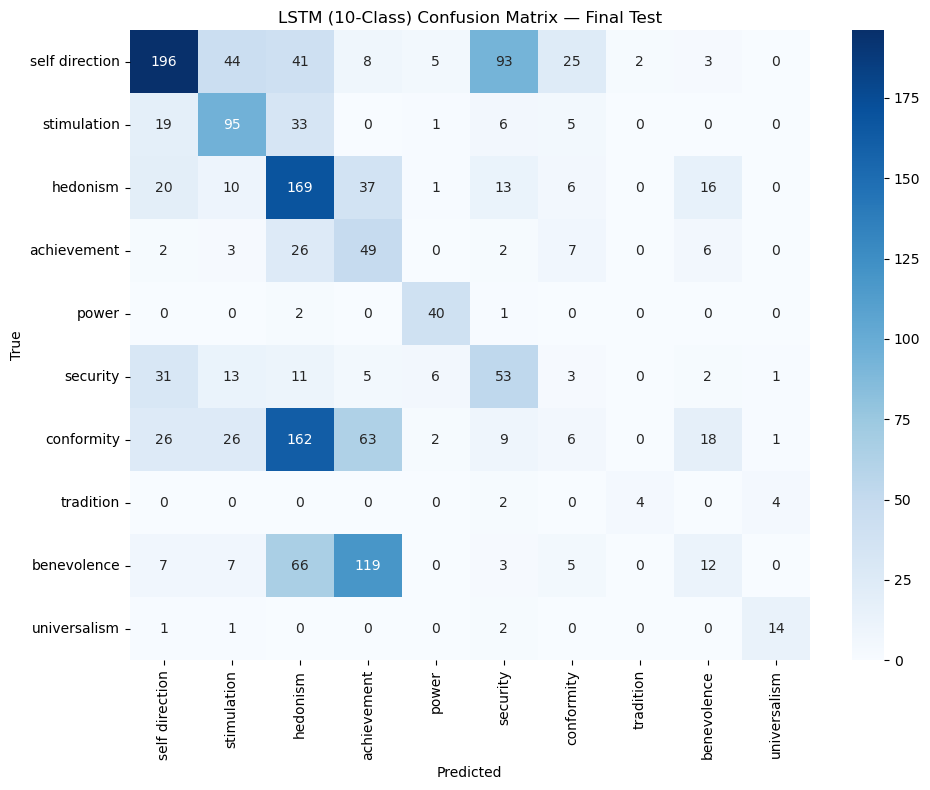

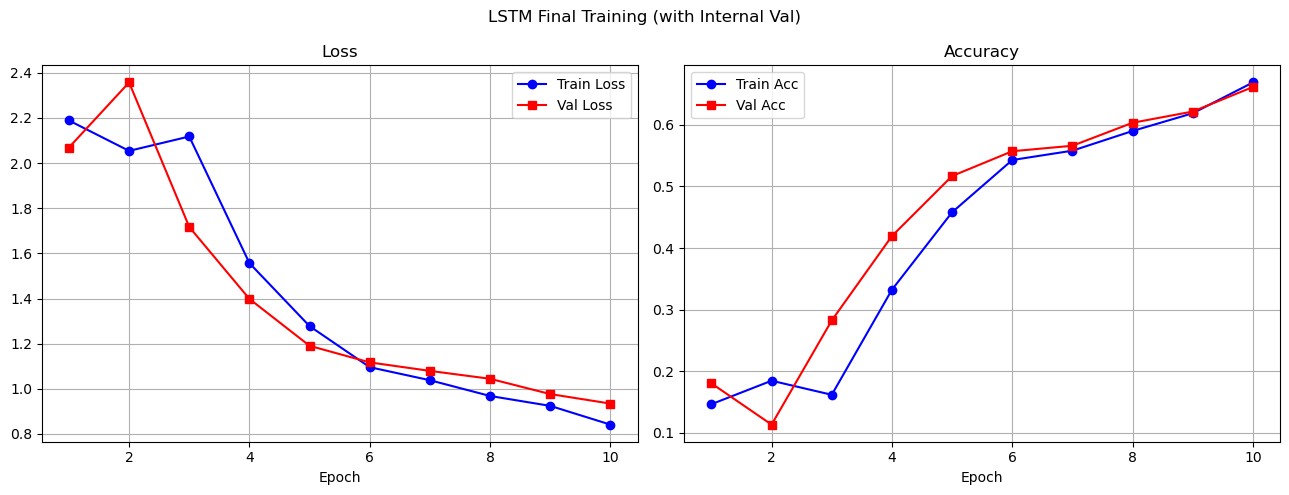

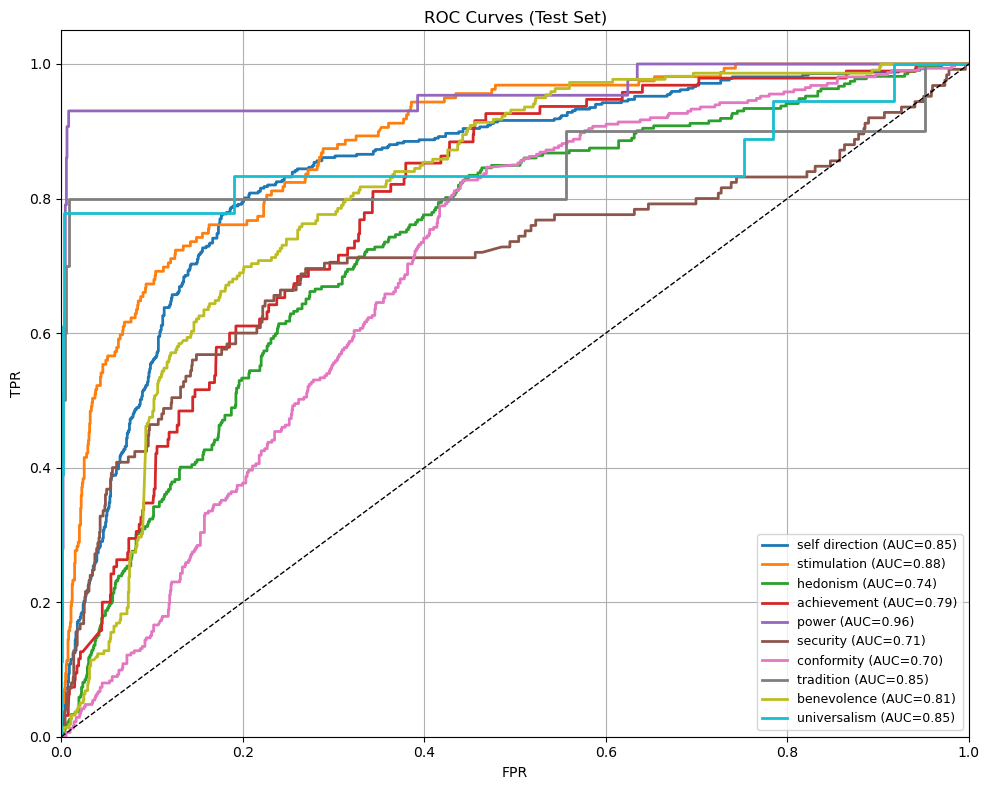

In [1]:
# ==============================
# 0. IMPORTS & SETUP (reproducibility + no leakage)
# ==============================
import pandas as pd
import numpy as np
import re
import os
import torch
import itertools
from nltk.stem import WordNetLemmatizer
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import label_binarize
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix, roc_curve, auc
)
from imblearn.over_sampling import RandomOverSampler
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Dense, Dropout, LSTM
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import warnings
warnings.filterwarnings('ignore')

# Reproducibility
np.random.seed(42)
tf.random.set_seed(42)

# Download NLTK quietly
import nltk
for res in ['punkt', 'wordnet', 'stopwords']:
    nltk.download(res, quiet=True)

print("✅ Libraries loaded & seeds set.")

# Force CPU — ensures reproducibility across runs
tf.config.set_visible_devices([], 'GPU')
os.environ["CUDA_VISIBLE_DEVICES"] = "-1"
print("✅ TensorFlow using CPU only")

# ==============================
# 1. LOAD & PREPROCESS DATASET
# ==============================
df = pd.read_csv('newextendeddataset.csv', encoding='utf-8-sig')

lemmatizer = WordNetLemmatizer()
def clean_text(text):
    if not isinstance(text, str):
        return ""
    text = text.lower()
    text = re.sub(r'[^\w\s]', ' ', text)
    text = re.sub(r'\d+', '', text)
    tokens = word_tokenize(text)
    stop_words = set(stopwords.words('english'))
    tokens = [t for t in tokens if t not in stop_words and t.isalpha()]
    tokens = [lemmatizer.lemmatize(t) for t in tokens]
    return ' '.join(tokens)

df['Base_Reviews'] = df['Base_Reviews'].apply(clean_text)
df['Base_Reviews'].dropna(inplace=True)

y_dict = {
    'self direction': 0, 'stimulation': 1, 'hedonism': 2, 'achievement': 3, 'power': 4,
    'security': 5, 'conformity': 6, 'tradition': 7, 'benevolence': 8, 'universalism': 9
}
df['category'] = df['category'].str.strip().str.lower().map(y_dict)
df = df.dropna(subset=['Base_Reviews', 'category'])
df['category'] = df['category'].astype(int)

X_all = df['Base_Reviews'].values
y_all = df['category'].values
n_classes = 10

print(f"✅ Preprocessing done. Samples: {len(X_all)} | Classes: {np.bincount(y_all)}")

# === Device Setup ===
device = torch.device("mps") if torch.backends.mps.is_available() else torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
os.environ["CUDA_VISIBLE_DEVICES"] = "-1"  # disable GPU for TF
os.environ["TF_ENABLE_ONEDNN_OPTS"] = "0"

# Force TensorFlow to use CPU (critical for stability with PyTorch MPS)
import tensorflow as tf
tf.config.set_visible_devices([], 'GPU')
print("✅ TensorFlow will use CPU only")

# ==============================
# 2. SPLIT: 85% Train / 15% Test (Stratified) ← TEST FROZEN!
# ==============================
X_train_raw, X_test_raw, y_train_raw, y_test_int = train_test_split(
    X_all, y_all, test_size=0.15, random_state=42, stratify=y_all
)

print(f"\n📊 Final Splits:")
print(f"→ Train (85%): {len(X_train_raw)} | Test (15%): {len(X_test_raw)}")
print(f"→ Train classes: {np.bincount(y_train_raw)}")
print(f"→ Test classes:  {np.bincount(y_test_int)}")

# ==============================
# 3. GRID SEARCH + 3-FOLD CV ON TRAIN (85%) → Select Best HPs
# ==============================
print(f"\n🔍 Grid Search + 3-Fold CV on TRAIN (85%)...")

# Same HP grid as others (for fair comparison)
LR_LIST = [1e-3, 1e-4]
BATCH_LIST = [32, 64]
EPOCHS_LIST = [6, 10]
DROPOUT_LIST = [0.2, 0.5]
LSTM_UNITS_LIST = [32, 64]

maxlen = 100
grid_results = []

skf_inner = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

for lr in LR_LIST:
    for bs in BATCH_LIST:
        for ep in EPOCHS_LIST:
            for do in DROPOUT_LIST:
                for lu in LSTM_UNITS_LIST:
                    print(f"  → Trying: lr={lr}, bs={bs}, ep={ep}, do={do}, lstm_units={lu}")
                    
                    cv_scores = []
                    for fold, (tr_idx, val_idx) in enumerate(skf_inner.split(X_train_raw, y_train_raw), 1):
                        X_tr_raw = X_train_raw[tr_idx]
                        X_v_raw = X_train_raw[val_idx]
                        y_tr_int = y_train_raw[tr_idx]
                        y_v_int = y_train_raw[val_idx]
                        
                        # ✅ Tokenizer FIT ONLY on fold-train
                        tokenizer = Tokenizer()
                        tokenizer.fit_on_texts(X_tr_raw)
                        vocab = len(tokenizer.word_index) + 1
                        
                        # Encode
                        X_tr_seq = tokenizer.texts_to_sequences(X_tr_raw)
                        X_v_seq = tokenizer.texts_to_sequences(X_v_raw)
                        X_tr_pad = pad_sequences(X_tr_seq, maxlen=maxlen, padding='post')
                        X_v_pad = pad_sequences(X_v_seq, maxlen=maxlen, padding='post')
                        
                        # ✅ Oversample ONLY fold-train
                        ros = RandomOverSampler(random_state=42)
                        X_tr_res, y_tr_res_int = ros.fit_resample(X_tr_pad, y_tr_int)
                        y_tr_res = to_categorical(y_tr_res_int, num_classes=n_classes)
                        y_v_cat = to_categorical(y_v_int, num_classes=n_classes)
                        
                        # ✅ LSTM — EXACTLY as in your original (no change!)
                        model = Sequential([
                            Embedding(vocab, 128, input_length=maxlen),
                            LSTM(lu, 
                                 dropout=do,
                                 recurrent_dropout=0.0,
                                 return_sequences=True),
                            Dropout(do),
                            LSTM(lu,
                                 dropout=do,
                                 recurrent_dropout=0.0),
                            Dropout(do),
                            Dense(64, activation='relu'),
                            Dense(n_classes, activation='softmax')
                        ])
                        model.compile(
                            optimizer=Adam(learning_rate=lr),
                            loss='categorical_crossentropy',
                            metrics=['accuracy']
                        )
                        
                        # Train (fixed epochs for fairness in CV)
                        model.fit(
                            X_tr_res, y_tr_res,
                            epochs=ep,
                            batch_size=bs,
                            verbose=0
                        )
                        
                        # Evaluate on *original* fold-val (no oversampling)
                        _, val_acc = model.evaluate(X_v_pad, y_v_cat, verbose=0)
                        cv_scores.append(val_acc)
                    
                    mean_cv = np.mean(cv_scores)
                    std_cv = np.std(cv_scores)
                    print(f"    → CV Acc: {mean_cv:.4f} ± {std_cv:.4f}")
                    
                    grid_results.append({
                        'lr': lr, 'batch_size': bs, 'epochs': ep,
                        'dropout': do, 'lstm_units': lu,
                        'cv_mean_acc': mean_cv, 'cv_std_acc': std_cv
                    })

# Select best by mean CV accuracy
grid_df = pd.DataFrame(grid_results).sort_values('cv_mean_acc', ascending=False)
best = grid_df.iloc[0]
print(f"\n✅ Best HPs by 3-Fold CV Acc ({best['cv_mean_acc']:.4f} ± {best['cv_std_acc']:.4f}):")
print({k: v for k, v in best.items() if k not in ['cv_mean_acc', 'cv_std_acc']})

# ==============================
# 4. 5-FOLD CV ON TRAIN (85%) WITH BEST HPs (Final Estimate)
# ==============================
print(f"\n🚀 5-Fold CV on TRAIN (85%) with best HPs...")

skf_outer = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_results = []

for fold, (tr_idx, val_idx) in enumerate(skf_outer.split(X_train_raw, y_train_raw), 1):
    print(f"\n--- Fold {fold}/5 ---")
    
    X_tr_raw = X_train_raw[tr_idx]
    X_v_raw = X_train_raw[val_idx]
    y_tr_int = y_train_raw[tr_idx]
    y_v_int = y_train_raw[val_idx]
    
    # Tokenizer & encode
    tokenizer = Tokenizer()
    tokenizer.fit_on_texts(X_tr_raw)
    vocab = len(tokenizer.word_index) + 1
    
    X_tr_seq = tokenizer.texts_to_sequences(X_tr_raw)
    X_v_seq = tokenizer.texts_to_sequences(X_v_raw)
    X_tr_pad = pad_sequences(X_tr_seq, maxlen=maxlen, padding='post')
    X_v_pad = pad_sequences(X_v_seq, maxlen=maxlen, padding='post')
    
    # Oversample fold-train only
    ros = RandomOverSampler(random_state=42)
    X_tr_res, y_tr_res_int = ros.fit_resample(X_tr_pad, y_tr_int)
    y_tr_res = to_categorical(y_tr_res_int, num_classes=n_classes)
    y_v_cat = to_categorical(y_v_int, num_classes=n_classes)
    
    # Build LSTM with BEST HPs (✅ unchanged architecture)
    model = Sequential([
        Embedding(vocab, 128, input_length=maxlen),
        LSTM(int(best['lstm_units']), 
             dropout=float(best['dropout']),
             recurrent_dropout=0.0,
             return_sequences=True),
        Dropout(float(best['dropout'])),
        LSTM(int(best['lstm_units']),
             dropout=float(best['dropout']),
             recurrent_dropout=0.0),
        Dropout(float(best['dropout'])),
        Dense(64, activation='relu'),
        Dense(n_classes, activation='softmax')
    ])
    model.compile(
        optimizer=Adam(learning_rate=float(best['lr'])),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    
    # Train
    model.fit(
        X_tr_res, y_tr_res,
        epochs=int(best['epochs']),
        batch_size=int(best['batch_size']),
        verbose=0
    )
    
    # Evaluate on fold-val
    _, val_acc = model.evaluate(X_v_pad, y_v_cat, verbose=0)
    print(f"  → Fold {fold} Val Acc: {val_acc:.4f}")
    
    cv_results.append({'fold': fold, 'val_acc': val_acc})

# Summarize CV
cv_df = pd.DataFrame(cv_results)
mean_cv = cv_df['val_acc'].mean()
std_cv = cv_df['val_acc'].std()
print(f"\n📊 5-Fold CV on TRAIN (85%): {mean_cv:.4f} ± {std_cv:.4f}")

# ==============================
# 5. FINAL MODEL: Retrain on FULL TRAIN (85%) → Test on HELD-OUT (15%)
# ==============================
print(f"\n🎯 Retraining final LSTM on FULL TRAIN (85%)...")

# Tokenizer on full train
final_tokenizer = Tokenizer()
final_tokenizer.fit_on_texts(X_train_raw)
vocab_final = len(final_tokenizer.word_index) + 1

# Encode
X_train_seq = final_tokenizer.texts_to_sequences(X_train_raw)
X_test_seq = final_tokenizer.texts_to_sequences(X_test_raw)
X_train_pad = pad_sequences(X_train_seq, maxlen=maxlen, padding='post')
X_test_pad = pad_sequences(X_test_seq, maxlen=maxlen, padding='post')

# Oversample full train only
ros_final = RandomOverSampler(random_state=42)
X_train_res, y_train_res_int = ros_final.fit_resample(X_train_pad, y_train_raw)
y_train_res = to_categorical(y_train_res_int, num_classes=n_classes)
y_test_cat = to_categorical(y_test_int, num_classes=n_classes)

# Final LSTM (✅ identical to original)
final_model = Sequential([
    Embedding(vocab_final, 128, input_length=maxlen),
    LSTM(int(best['lstm_units']), 
         dropout=float(best['dropout']),
         recurrent_dropout=0.0,
         return_sequences=True),
    Dropout(float(best['dropout'])),
    LSTM(int(best['lstm_units']),
         dropout=float(best['dropout']),
         recurrent_dropout=0.0),
    Dropout(float(best['dropout'])),
    Dense(64, activation='relu'),
    Dense(n_classes, activation='softmax')
])
final_model.compile(
    optimizer=Adam(learning_rate=float(best['lr'])),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Use small internal val for early stopping
X_tr, X_val_int, y_tr, y_val_int = train_test_split(
    X_train_res, y_train_res, test_size=0.1, random_state=42, stratify=y_train_res_int
)

es = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

history = final_model.fit(
    X_tr, y_tr,
    validation_data=(X_val_int, y_val_int),
    epochs=int(best['epochs']),
    batch_size=int(best['batch_size']),
    callbacks=[es],
    verbose=1
)

# Save
final_model.save('./final_lstm_10class_cv.h5')
with open('./final_lstm_tokenizer_cv.pkl', 'wb') as f:
    pickle.dump(final_tokenizer, f)
print("✅ Final LSTM model & tokenizer saved.")

# ==============================
# 6. FINAL EVALUATION ON TEST SET (15%)
# ==============================
idx_to_class = {v: k for k, v in y_dict.items()}
class_names = [idx_to_class[i] for i in range(n_classes)]

test_loss, test_acc = final_model.evaluate(X_test_pad, y_test_cat, verbose=0)
print(f"\n🟩 FINAL TEST ACCURACY (Held-Out, Natural Distribution): {test_acc:.4f}")

y_pred_proba = final_model.predict(X_test_pad, verbose=0)
y_pred = np.argmax(y_pred_proba, axis=1)

print("\n=== FINAL CLASSIFICATION REPORT (TEST SET) ===")
print(classification_report(y_test_int, y_pred, target_names=class_names, digits=4))

# Confusion Matrix
cm = confusion_matrix(y_test_int, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('LSTM (10-Class) Confusion Matrix — Final Test')
plt.xlabel('Predicted'); plt.ylabel('True')
plt.tight_layout()
plt.savefig('LSTM_10class_ConfusionMatrix_Test.png', dpi=300, bbox_inches='tight')
plt.show()

# Learning Curves
plt.figure(figsize=(13, 5))
epochs = range(1, len(history.history['loss']) + 1)

plt.subplot(1, 2, 1)
plt.plot(epochs, history.history['loss'], 'b-o', label='Train Loss')
plt.plot(epochs, history.history['val_loss'], 'r-s', label='Val Loss')
plt.title('Loss'); plt.xlabel('Epoch'); plt.legend(); plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(epochs, history.history['accuracy'], 'b-o', label='Train Acc')
plt.plot(epochs, history.history['val_accuracy'], 'r-s', label='Val Acc')
plt.title('Accuracy'); plt.xlabel('Epoch'); plt.legend(); plt.grid(True)

plt.suptitle('LSTM Final Training (with Internal Val)')
plt.tight_layout()
plt.savefig('LSTM_10class_LearningCurves.png', dpi=300, bbox_inches='tight')
plt.show()

# ROC Curves (One-vs-Rest)
y_test_bin = label_binarize(y_test_int, classes=list(range(n_classes)))
plt.figure(figsize=(10, 8))
colors = itertools.cycle(plt.cm.tab10.colors)
for i, color in zip(range(n_classes), colors):
    fpr_i, tpr_i, _ = roc_curve(y_test_bin[:, i], y_pred_proba[:, i])
    auc_i = auc(fpr_i, tpr_i)
    plt.plot(fpr_i, tpr_i, color=color, lw=2, label=f'{class_names[i]} (AUC={auc_i:.2f})')

plt.plot([0,1], [0,1], 'k--', lw=1)
plt.xlim([0.0, 1.0]); plt.ylim([0.0, 1.05])
plt.xlabel('FPR'); plt.ylabel('TPR'); plt.title('ROC Curves (Test Set)')
plt.legend(fontsize=9, loc='lower right')
plt.grid(True)
plt.tight_layout()
plt.savefig('LSTM_10class_ROC_Test.png', dpi=300, bbox_inches='tight')
plt.show()